# Notebook 3 — Bayesian linear fit with `emcee`

In this notebook, we extend the Gaussian linear-fit problem from Notebooks 1 and 2 to a Bayesian framework.

We define a prior, likelihood and posterior for the parameters, then use Markov Chain Monte Carlo (MCMC) with `emcee` to sample the posterior distribution.

The goal is to move from a single best-fit point to a distribution of plausible parameter values, while keeping a problem simple enough that the MCMC result can be checked against the analytic solution.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import emcee
import corner

np.random.seed(42)
plt.style.use("default")


## 1. Data and assumptions

We use the same dataset as in Notebooks 1 and 2, taken from Exercise 1 of Hogg, Bovy & Lang (2010). As before, only data points 5–20 are included in the fit.

We assume:

- independent Gaussian uncertainties in $y$;
- negligible uncertainties in $x$;
- no correlations between the measurements.

The linear model is

$$
y_i = m x_i + b,
$$

with parameter vector

$$
\theta = (b,m).
$$


In [2]:
ID = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
               11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

x = np.array([201, 244, 47, 287, 203, 58, 210, 202, 198, 158,
              165, 201, 157, 131, 166, 160, 186, 125, 218, 146])

y = np.array([592, 401, 583, 402, 495, 173, 479, 504, 510, 416,
              393, 442, 317, 311, 400, 337, 423, 334, 533, 344])

sigma_y = np.array([61, 25, 38, 15, 21, 15, 27, 14, 30, 16,
                    14, 25, 52, 16, 34, 31, 42, 26, 16, 22])

mask = ID >= 5
x_fit = x[mask]
y_fit = y[mask]
sigma_y_fit = sigma_y[mask]


## 2. Bayesian model

Bayes' theorem gives

$$
p(\theta \mid D) \propto p(D \mid \theta)\,p(\theta),
$$

where $p(D\mid\theta)$ is the likelihood, $p(\theta)$ is the prior and $p(\theta\mid D)$ is the posterior.

For independent Gaussian uncertainties, the chi-square is

$$
\chi^2(b,m)
=
\sum_i
\frac{\left[y_i-(mx_i+b)\right]^2}{\sigma_{y,i}^2}.
$$

Because the measurement uncertainties are fixed, the Gaussian log-likelihood can be used up to an additive constant:

$$
\log L(b,m)
=
-\frac{1}{2}\chi^2(b,m)+\text{constant}.
$$

We adopt broad uniform priors

$$
-100 < b < 200,
\qquad
0 < m < 5.
$$

Inside this region, the log-prior is constant and can be set to zero; outside it, it is $-\infty$. Therefore, up to an additive constant,

$$
\log p(\theta\mid D)
=
\log p(\theta)+\log L(\theta).
$$


In [3]:
def compute_chi2(theta, x, y, sigma_y):
    b, m = theta
    y_model = m * x + b
    residuals = y - y_model
    return np.sum((residuals / sigma_y) ** 2)


def log_likelihood(theta, x, y, sigma_y):
    return -0.5 * compute_chi2(theta, x, y, sigma_y)


def log_prior(theta):
    b, m = theta
    if -100 < b < 200 and 0 < m < 5:
        return 0.0
    return -np.inf


def log_posterior(theta, x, y, sigma_y):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, sigma_y)


def neg_log_posterior(theta, x, y, sigma_y):
    lp = log_posterior(theta, x, y, sigma_y)
    if not np.isfinite(lp):
        return 1e100
    return -lp


## 3. Maximum-a-posteriori estimate

Before running MCMC, we locate the maximum of the posterior distribution:

$$
\theta_{\rm MAP}
=
\operatorname*{arg\,max}_{\theta} p(\theta\mid D).
$$

Because the likelihood maximum lies well inside the flat-prior bounds, the MAP and maximum-likelihood estimates coincide here:

$$
\theta_{\rm MAP}=\theta_{\rm MLE}.
$$

This gives a useful reference point for initializing and checking the sampler.


In [4]:
theta0 = np.array([30.0, 2.0])

result = minimize(
    neg_log_posterior,
    theta0,
    args=(x_fit, y_fit, sigma_y_fit)
)

theta_best = result.x
b_best, m_best = theta_best

print(f"MAP estimate: b = {b_best:.4f}, m = {m_best:.6f}")
print(f"chi^2_min = {compute_chi2(theta_best, x_fit, y_fit, sigma_y_fit):.4f}")


MAP estimate: b = 34.0478, m = 2.239921
chi^2_min = 18.6808


## 4. Sampling the posterior with MCMC

The optimizer returns only one point. MCMC instead generates samples whose density follows the posterior distribution

$$
p(b,m\mid D).
$$

We use the affine-invariant ensemble sampler implemented in `emcee`. Several walkers explore the two-dimensional parameter space simultaneously, starting close to the MAP estimate.


In [5]:
ndim = 2
nwalkers = 32
nsteps = 5000

pos = theta_best + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_posterior,
    args=(x_fit, y_fit, sigma_y_fit)
)

_ = sampler.run_mcmc(pos, nsteps, progress=False)
samples = sampler.get_chain()

print("Chain shape:", samples.shape)


Chain shape: (5000, 32, 2)


## 5. Trace plots

Trace plots show the evolution of every walker as a function of MCMC step.

An initial transient is expected while the walkers move from their starting positions toward the high-probability region. After this phase, the chains should fluctuate around a stable region without a systematic drift.


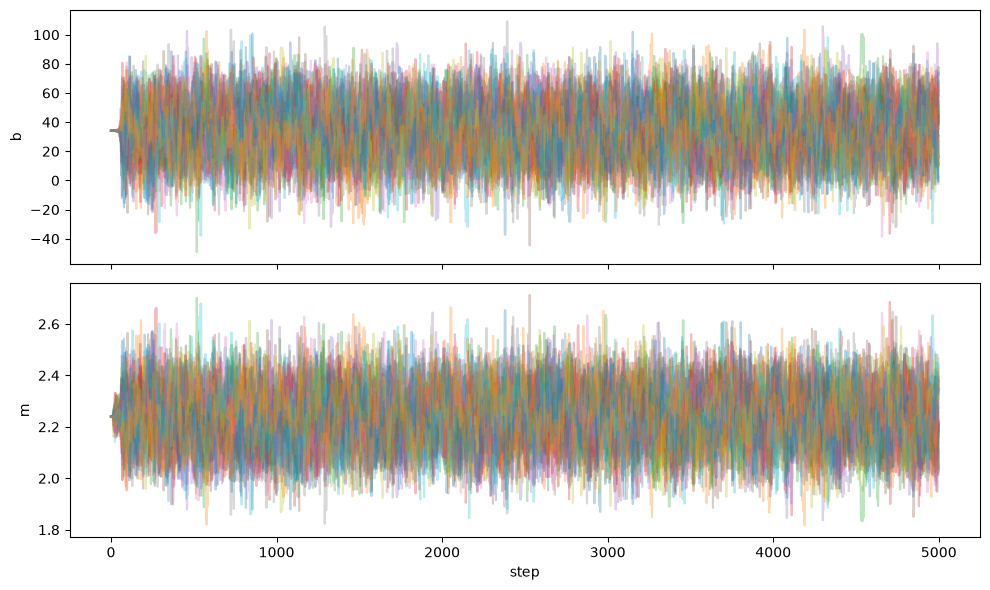

In [6]:
labels = ["b", "m"]

fig, axes = plt.subplots(ndim, figsize=(10, 6), sharex=True)

for i in range(ndim):
    axes[i].plot(samples[:, :, i], alpha=0.3)
    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel("step")
plt.tight_layout()
plt.show()


## 6. MCMC diagnostics

Visual inspection is useful, but it is not sufficient by itself. We therefore also examine the mean acceptance fraction, the integrated autocorrelation time $\tau$, and the effective sample size.

Successive MCMC states are correlated, so the number of stored samples is larger than the number of effectively independent samples. A useful estimate is

$$
N_{\rm eff}
\approx
\frac{N_{\rm walkers}N_{\rm retained\ steps}}{\tau}.
$$

We discard the first 500 steps as burn-in before computing posterior summaries.


In [7]:
discard = 500

acceptance = np.mean(sampler.acceptance_fraction)
tau = sampler.get_autocorr_time(discard=discard)

n_retained = nwalkers * (nsteps - discard)
ess = n_retained / tau

print(f"Mean acceptance fraction: {acceptance:.3f}")
print("Autocorrelation times:", tau)
print("Effective sample sizes:", ess)


Mean acceptance fraction: 0.718
Autocorrelation times: [29.37562728 29.04301833]
Effective sample sizes: [4902.02297997 4958.16234889]


The retained chains span approximately 153–155 autocorrelation times and yield about 4,900 effective samples for each parameter. Together with the stable trace plots, these diagnostics indicate adequate sampling for this simple two-parameter posterior. The mean acceptance fraction is relatively high, but it does not indicate a sampling problem here.

## 7. Posterior samples and parameter estimates

After discarding the burn-in period, the samples from all walkers are combined into one array. These samples approximate draws from the joint posterior

$$
p(b,m\mid D).
$$

We summarize each marginalized posterior with its 16th, 50th and 84th percentiles. The median is used as the central value, while the 16th–84th percentile interval gives the quoted uncertainty range.


In [8]:
flat_samples = sampler.get_chain(discard=discard, flat=True)

b_samples = flat_samples[:, 0]
m_samples = flat_samples[:, 1]

b_q16, b_median, b_q84 = np.percentile(b_samples, [16, 50, 84])
m_q16, m_median, m_q84 = np.percentile(m_samples, [16, 50, 84])

b_minus = b_median - b_q16
b_plus = b_q84 - b_median
m_minus = m_median - m_q16
m_plus = m_q84 - m_median

print(f"Posterior samples: {flat_samples.shape[0]}")
print(f"b = {b_median:.2f} -{b_minus:.2f} +{b_plus:.2f}")
print(f"m = {m_median:.3f} -{m_minus:.3f} +{m_plus:.3f}")


Posterior samples: 144000
b = 34.15 -18.22 +18.23
m = 2.238 -0.107 +0.108


## 8. Posterior visualization

The corner plot shows both the marginalized one-dimensional posterior distributions and the joint posterior distribution of $b$ and $m$.

A strong negative correlation is expected: increasing the slope can be partly compensated by decreasing the intercept, and vice versa.


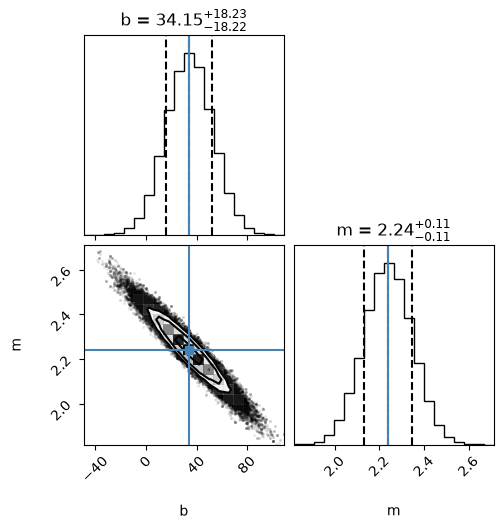

In [9]:
fig = corner.corner(
    flat_samples,
    labels=["b", "m"],
    truths=theta_best,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True
)
plt.show()


## 9. Conclusion

In this notebook, we reformulated the linear-fitting problem in a Bayesian framework and sampled the posterior distribution with `emcee`.

The MCMC posterior gives

$$
b = 34.15^{+18.23}_{-18.22},
\qquad
m = 2.238^{+0.108}_{-0.107}.
$$

The posterior summaries agree with the MAP estimate and with the analytic weighted least-squares result from Notebook 1. This agreement is an important validation: MCMC is not expected to give a different answer for this linear-Gaussian problem. Its purpose here is to recover the full posterior distribution using a method that can later be applied when no simple analytic solution exists.

The corner plot also reveals the strong negative correlation between slope and intercept, illustrating why Bayesian inference is useful for studying joint parameter constraints rather than only a single best-fit point.
